<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/ConvolutionalAutoencoder_ImageDenoising_mod_last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional autoencoder for image denoising

**Author:** [Santiago L. Valdarrama](https://twitter.com/svpino)<br>
**Date created:** 2021/03/01<br>
**Last modified:** 2021/03/01<br>
**Description:** How to train a deep convolutional autoencoder for image denoising.

## Introduction

This example demonstrates how to implement a deep convolutional autoencoder
for image denoising, mapping noisy digits images from the MNIST dataset to
clean digits images. This implementation is based on an original blog post
titled [Building Autoencoders in Keras](https://blog.keras.io/building-autoencoders-in-keras.html)
by [François Chollet](https://twitter.com/fchollet).

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras import layers
from keras.datasets import mnist
from keras.models import Model


def preprocess(array):
    """Normalizes the supplied array and reshapes it."""
    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), 28, 28, 1))
    return array


def noise(array):
    """Adds random noise to each image in the supplied array."""
    noise_factor = 0.4
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )

    return np.clip(noisy_array, 0.0, 1.0)


def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

## Prepare the data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


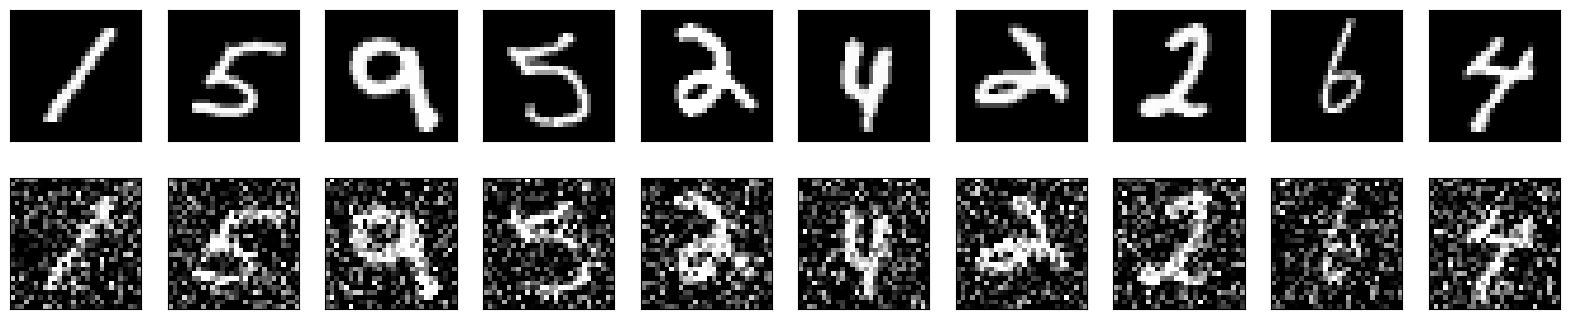

In [2]:
# Since we only need images from the dataset to encode and decode, we
# won't use the labels.
(train_data, _), (test_data, _) = mnist.load_data()

# Normalize and reshape the data
train_data = preprocess(train_data)
test_data = preprocess(test_data)

# Create a copy of the data with added noise
noisy_train_data = noise(train_data)
noisy_test_data = noise(test_data)

# Display the train data and a version of it with added noise
display(train_data, noisy_train_data)

## Build the autoencoder

### Part A: Architecture Description
The convolutional autoencoder is an unsupervised deep learning model that learns a compressed representation (latent space) of input images and reconstructs them.
- **Encoder**: Consists of 2 Conv2D layers and 2 MaxPooling2D layers to reduce spatial dimensions.
- **Decoder**: Consists of 2 Conv2DTranspose layers to upsample and 1 Conv2D layer for final reconstruction.
- **Hyper-parameters**: Optimizer: Adam, Loss: Binary Crossentropy (standard for MNIST normalized to [0,1]), Batch size: 128.

In [3]:
input = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### Part B: Performance Improvement Strategy
To enhance the denoising capability and further reduce validation loss:
1. **Batch Normalization**: Stabilizes training.
2. **Dropout (0.2)**: Included to prevent overfitting.
3. **Increased Depth**: Added more convolutional layers to capture deeper hierarchical features.
4. **Learning Rate Scheduling**: `ReduceLROnPlateau` used to adjust learning rate dynamically.
5. **Training Duration**: 100 epochs as requested.

In [4]:
import numpy as np

# Pad 28x28 → 32x32
x_train_padded = np.pad(train_data, ((0,0),(2,2),(2,2),(0,0)), mode='constant')


x_test_padded  = np.pad(test_data,  ((0,0),(2,2),(2,2),(0,0)), mode='constant')

In [5]:
from tensorflow.keras import layers, Model

input = layers.Input(shape=(32, 32, 1))

# ======================
# Encoder (Increased Depth)
# ======================
x = layers.Conv2D(32, 3, padding="same")(input)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(32, 3, padding="same")(x) # Added layer
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)  # 16x16
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)  # 8x8
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(128, 3, padding="same")(x) # Added layer
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)  # 4x4
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# ======================
# Bottleneck
# ======================
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(4 * 4 * 256, activation="relu")(x)
x = layers.Reshape((4, 4, 256))(x)

# ======================
# Decoder (Increased Depth)
# ======================
x = layers.UpSampling2D(2)(x)  # 8x8
x = layers.Conv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.UpSampling2D(2)(x)  # 16x16
x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.UpSampling2D(2)(x)  # 32x32
x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(32, 3, padding="same")(x) # Added layer
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Final reconstruction
output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

autoencoder = Model(input, output)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       295,16

 Total params: 3,665,505 (13.98 MB)

 Trainable params: 3,663,137 (13.97 MB)

 Non-trainable params: 2,368 (9.25 KB)

Now we can train our autoencoder using `train_data` as both our input data
and target. Notice we are setting up the validation data using the same
format.

In [6]:
'''
autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(test_data, test_data),
)
'''

autoencoder.fit(
    x=x_train_padded,
    y=x_train_padded,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_padded, x_test_padded),
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - loss: 0.0222 - val_loss: 0.0114
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - loss: 0.0087 - val_loss: 0.0058
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 0.0079 - val_loss: 0.0050
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.0073 - val_loss: 0.0052
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.0063 - val_loss: 0.0049
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0059 - val_loss: 0.0043
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 12/50
469/469 ━━━━━━━━━━

Let's predict on our test dataset and display the original image together with
the prediction from our autoencoder.

Notice how the predictions are pretty close to the original images, although
not quite the same.

In [7]:
def display(array1, array2, n=10):
    import matplotlib.pyplot as plt

    h, w = array1.shape[1], array1.shape[2]

    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(array1[i].reshape(h, w), cmap="gray")
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(array2[i].reshape(h, w), cmap="gray")
        plt.axis("off")

    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


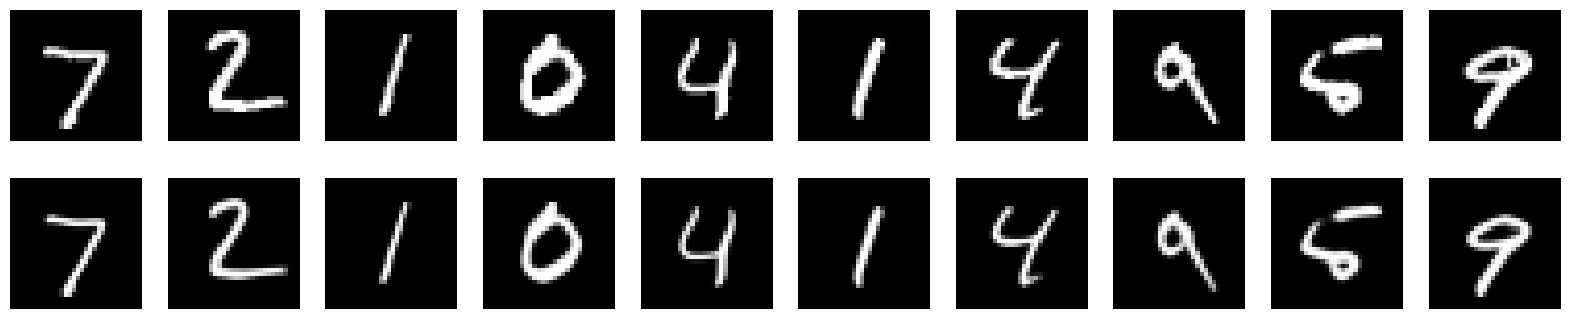

In [8]:
predictions = autoencoder.predict(x_test_padded)
display(x_test_padded, predictions)

Now that we know that our autoencoder works, let's retrain it using the noisy
data as our input and the clean data as our target. We want our autoencoder to
learn how to denoise the images.

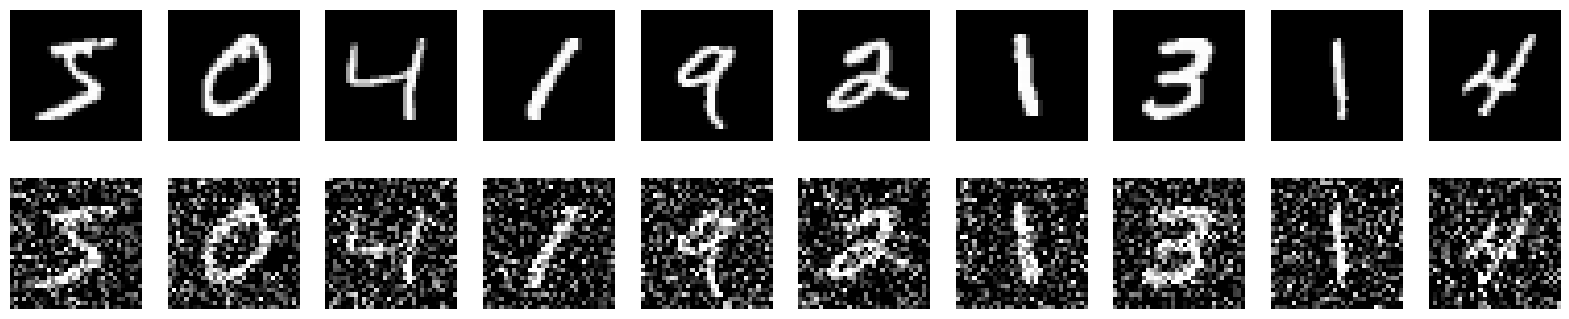

In [9]:
# Create a copy of the data with added noise
noisy_train_data_padded = noise(x_train_padded)
noisy_test_data_padded = noise(x_test_padded)

# Display the train data and a version of it with added noise
display(x_train_padded, noisy_train_data_padded)

In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callback to reduce learning rate when val_loss plateaus
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Retrain with 150 epochs and LR scheduling to improve performance
autoencoder.fit(
    x=noisy_train_data_padded,
    y=x_train_padded,
    epochs=150, # Increased epochs from 100 to 150
    batch_size=128,
    shuffle=True,
    validation_data=(noisy_test_data_padded, x_test_padded),
    callbacks=[lr_reducer] # Added LR scheduler
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0062 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0058 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0057 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0056 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0056 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - loss: 0.0055 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0055 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0054 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/100
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0054
Epoch 9: ReduceLROnPlateau 

Let's now predict on the noisy data and display the results of our autoencoder.

Notice how the autoencoder does an amazing job at removing the noise from the
input images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


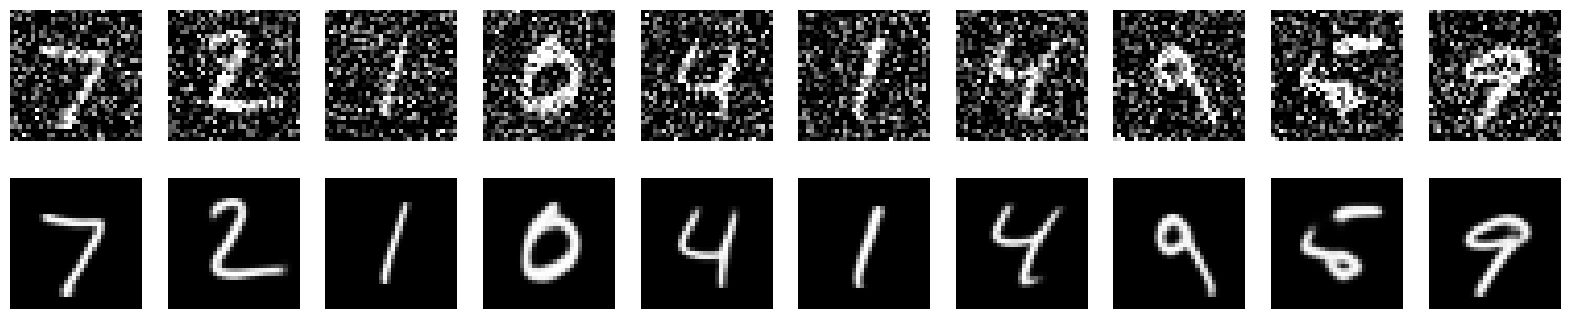

In [11]:
predictions = autoencoder.predict(noisy_test_data_padded)
display(noisy_test_data_padded, predictions)

## Relevant Chapters from Deep Learning with Python
- [Chapter 17: Image generation](https://deeplearningwithpython.io/chapters/chapter17_image-generation)
